In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import warnings
warnings.filterwarnings('ignore')

In [173]:
from sklearn.datasets import fetch_california_housing

In [174]:
data=fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [175]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [176]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [177]:
df=pd.DataFrame(data.data,columns=data.feature_names) #

In [178]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [179]:
df['price']=data.target

In [180]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [181]:
'''multicollinearity :one feature explained by all other features/VIF/CLUSTER MAP 
correlation : when two or more features are related '''

'multicollinearity :one feature explained by all other features/VIF/CLUSTER MAP \ncorrelation : when two or more features are related '

In [182]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

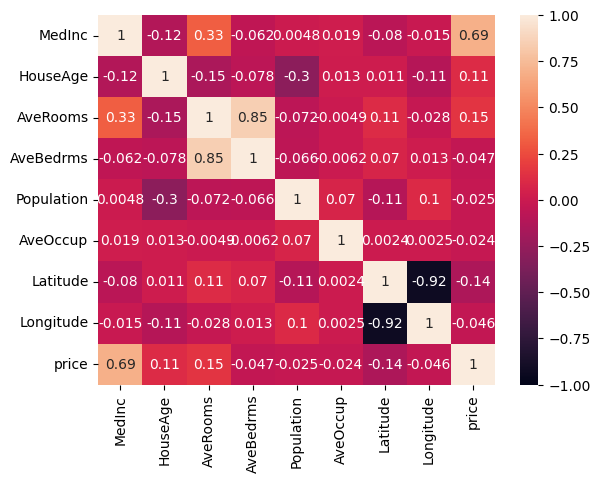

In [183]:
sns.heatmap(df.corr(),annot=True,vmin=-1,vmax=1)

In [184]:
'''Never remove both features from a correlated pair.
Remove only one from each pair.

How to decide which one to remove:

Remove the feature that:

Has lower correlation with target (price) after selecting pair of corelation 

Or is less interpretable

Or has higher VIF later

Heatmap = first filter
 VIF = final decision


'''

'Never remove both features from a correlated pair.\nRemove only one from each pair.\n\nHow to decide which one to remove:\n\nRemove the feature that:\n\nHas lower correlation with target (price) after selecting pair of corelation \n\nOr is less interpretable\n\nOr has higher VIF later\n\nHeatmap = first filter\n VIF = final decision\n\n\n'

In [185]:
'''Look at the heatmap to identify correlated features.

Look at the correlation with the target (price).

Randomly select 4 features to remove based on high correlation with another feature or low impact on the target.

Drop them from your dataset and verify. '''

'Look at the heatmap to identify correlated features.\n\nLook at the correlation with the target (price).\n\nRandomly select 4 features to remove based on high correlation with another feature or low impact on the target.\n\nDrop them from your dataset and verify. '

In [186]:
# cluster map table

<Figure size 400x500 with 0 Axes>

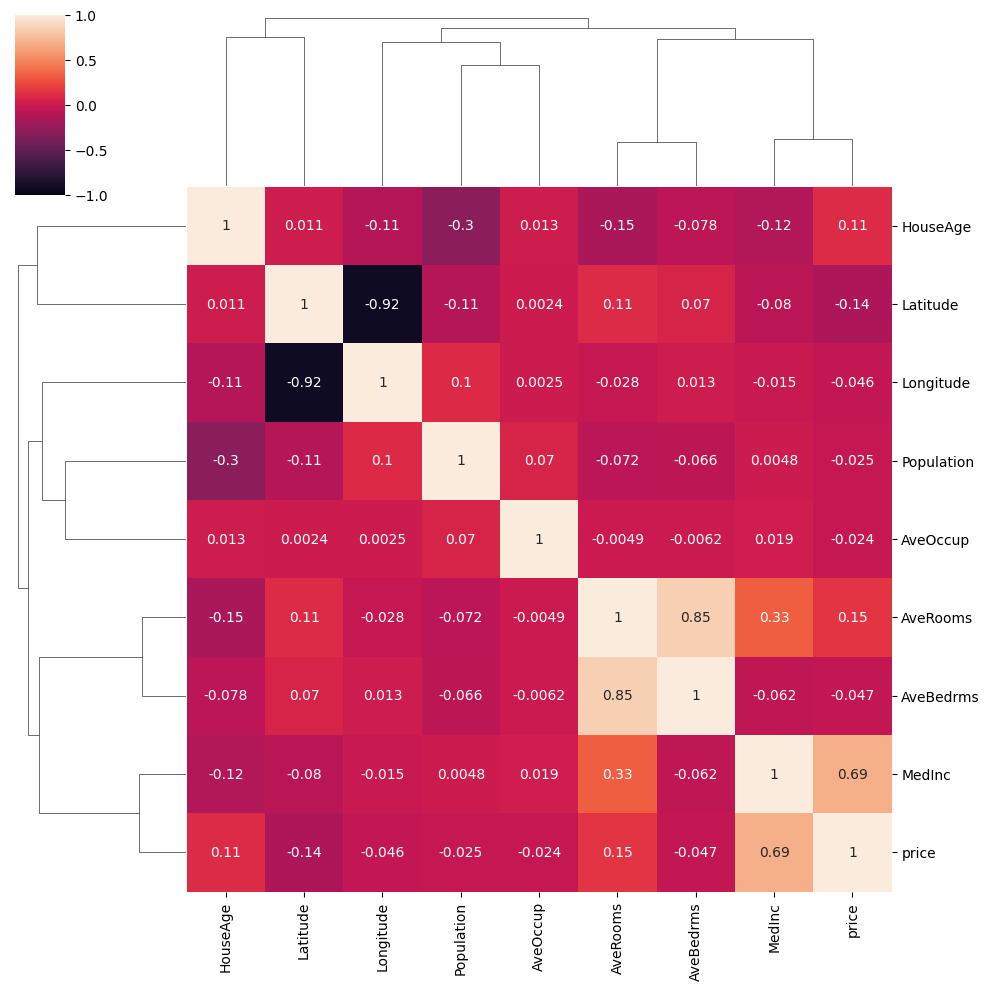

In [187]:
plt.figure(figsize=(4,5))
sns.clustermap(df.corr(),vmin=-1,vmax=1,annot=True)
plt.show()

In [188]:
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable


In [189]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [190]:
vif=pd.DataFrame()
vif["Feature"]=df.columns
vif['VIF']=[variance_inflation_factor(df.values, i) 
            for i in range(len(df.columns))]

In [191]:
vif

,Feature,VIF
0,MedInc,19.624998
1,HouseAge,7.592663
2,AveRooms,47.956351
3,AveBedrms,45.358192
4,Population,2.936078
5,AveOccup,1.099530
6,Latitude,568.497332
7,Longitude,640.064211
8,price,9.285659


In [192]:
# if vif is greater than 10 we drop the features ..one by one 
# we drop longitude then one by one 

In [193]:
df1=df.copy()

In [194]:
df1.drop("Longitude",axis=1,inplace=True)
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,0.847


In [195]:
vif = pd.DataFrame()
vif["Feature"] = df1.columns
vif['VIF'] =[ variance_inflation_factor(df1.values, i)
             for i in range(len(df1.columns))   ]

In [196]:
vif
# latitude vales are changed

,Feature,VIF
0,MedInc,18.639889
1,HouseAge,7.346583
2,AveRooms,44.714760
3,AveBedrms,42.072000
4,Population,2.796280
5,AveOccup,1.099394
6,Latitude,22.873934
7,price,9.193500


In [197]:
df1.drop("AveRooms",axis=1,inplace=True)
df1

,MedInc,HouseAge,AveBedrms,Population,AveOccup,Latitude,price
0,8.3252,41.0,1.023810,322.0,2.555556,37.88,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,37.85,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,37.85,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,37.85,3.422
...,...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,39.48,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,39.49,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,39.43,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,39.43,0.847


In [198]:
vif = pd.DataFrame()
vif["Feature"] = df1.columns
vif['VIF'] =[ variance_inflation_factor(df1.values, i)
             for i in range(len(df1.columns))]
vif

,Feature,VIF
0,MedInc,10.584081
1,HouseAge,7.260588
2,AveBedrms,6.440667
3,Population,2.762794
4,AveOccup,1.098719
5,Latitude,22.094483
6,price,8.674858


In [199]:
df1.drop("Latitude", axis=1, inplace=True)

vif = pd.DataFrame()
vif["Feature"] = df1.columns
vif['VIF'] =[ variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]
vif

,Feature,VIF
0,MedInc,8.855104
1,HouseAge,4.156145
2,AveBedrms,4.264253
3,Population,2.223926
4,AveOccup,1.098671
5,price,8.607339


In [200]:
# now we can build model as evrything below 10
df1

,MedInc,HouseAge,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,1.081081,565.0,2.181467,3.422
...,...,...,...,...,...,...
20635,1.5603,25.0,1.133333,845.0,2.560606,0.781
20636,2.5568,18.0,1.315789,356.0,3.122807,0.771
20637,1.7000,17.0,1.120092,1007.0,2.325635,0.923
20638,1.8672,18.0,1.171920,741.0,2.123209,0.847


In [201]:
x=df1.iloc[:,:-1]#independent
y=df1.iloc[:,-1]#target variable

In [202]:
x,

(       MedInc  HouseAge  AveBedrms  Population  AveOccup
 0      8.3252      41.0   1.023810       322.0  2.555556
 1      8.3014      21.0   0.971880      2401.0  2.109842
 2      7.2574      52.0   1.073446       496.0  2.802260
 3      5.6431      52.0   1.073059       558.0  2.547945
 4      3.8462      52.0   1.081081       565.0  2.181467
 ...       ...       ...        ...         ...       ...
 20635  1.5603      25.0   1.133333       845.0  2.560606
 20636  2.5568      18.0   1.315789       356.0  3.122807
 20637  1.7000      17.0   1.120092      1007.0  2.325635
 20638  1.8672      18.0   1.171920       741.0  2.123209
 20639  2.3886      16.0   1.162264      1387.0  2.616981
 
 [20640 rows x 5 columns],)

In [203]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: price, Length: 20640, dtype: float64

In [204]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=1)
x_train

,MedInc,HouseAge,AveBedrms,Population,AveOccup
5748,2.9148,15.0,1.105532,3164.0,2.692766
5592,3.1779,41.0,1.054825,1658.0,3.635965
2110,2.5111,49.0,0.964361,1290.0,2.704403
13901,2.5405,15.0,1.422326,2568.0,2.388837
18425,4.5033,7.0,1.101173,1739.0,2.549853
...,...,...,...,...,...
10955,1.7823,17.0,1.087156,1079.0,2.474771
17289,8.5608,42.0,1.011538,753.0,2.896154
5192,1.1326,42.0,1.006826,775.0,2.645051
12172,2.6322,10.0,0.951782,1323.0,2.773585


In [205]:
#scaling optional

In [206]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [207]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [208]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [209]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [210]:
model.coef_ # it is a multiple LR as ther are mutliple slopes 

array([ 0.8295202 ,  0.23888438,  0.02058888,  0.03902186, -0.05185743])

In [211]:
model.intercept_

np.float64(2.0765314825581394)

In [212]:
y_predict=model.predict(x_test)

In [213]:
#performance metrices
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [214]:
print(mean_absolute_error(y_test,y_predict))
print(mean_squared_error(y_test,y_predict))
print(r2_score(y_test,y_predict))

0.6046846522578225
0.6544937093127864
0.5021661718778507


In [215]:
score=r2_score(y_test,y_predict)
score

0.5021661718778507

In [216]:
#adjusted r square
1-((1-score)*len(y_test)-1)/((len(y_test))-x_test.shape[1]-1)

0.5018449622159152

In [217]:
# here number of features are low , that why we dropped features and check one by one 
# when features are 1000

In [218]:
#x=df.iloc[:,:-1]
#y=df.iloc[:,-1]

In [219]:
x.columns

Index(['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup'], dtype='object')

In [220]:
from sklearn.feature_selection import RFE

In [228]:
rfe=RFE(LinearRegression(),n_features_to_select=3)
rfe

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",3
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [229]:
rfe.fit(x,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",3
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [230]:
rfe.support_

array([ True,  True,  True, False, False])

In [231]:
x.columns

Index(['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup'], dtype='object')

In [232]:
rfe.ranking_

array([1, 1, 1, 3, 2])

In [226]:
rfe.predict(x) # since train test split not done we use x directly

array([4.20855682, 3.84593405, 3.94143516, ..., 0.92688114, 1.01824415,
       1.20824304], shape=(20640,))

In [227]:
#Question

'''If I select 5 columns using RFE and
I use VIF and remove features until 5 remain,
will the final 5 columns be the same?

✅ Correct Answer

Not necessarily.
They often differ because RFE and VIF optimize different objectives.
 
 What RFE cares about

“Which features best predict the target?” 

What VIF cares about

“Which features are redundant?”'''

'If I select 5 columns using RFE and\nI use VIF and remove features until 5 remain,\nwill the final 5 columns be the same?\n\n✅ Correct Answer\n\nNot necessarily.\nThey often differ because RFE and VIF optimize different objectives.\n\n What RFE cares about\n\n“Which features best predict the target?” \n\nWhat VIF cares about\n\n“Which features are redundant?”'